In [1]:
import osmnx as ox

In [2]:
tags = {
    "amenity": "bar"
}

bares = ox.features_from_place(
    "Buenos Aires, Argentina",
    tags
)

In [10]:
tags = {
    "natural": "water"
}

rio = ox.features_from_place(
    "Buenos Aires, Argentina",
    tags
)

In [12]:
rio

geometry  \
element  id                                                              
relation 27896       POLYGON ((-58.40919 -34.57541, -58.40922 -34.5...   
         532035      POLYGON ((-58.41542 -34.57184, -58.41557 -34.5...   
         533789      POLYGON ((-58.43479 -34.55531, -58.43472 -34.5...   
         1648132     POLYGON ((-58.45786 -34.54156, -58.45776 -34.5...   
         1655099     POLYGON ((-58.41564 -34.57716, -58.41562 -34.5...   
...                                                                ...   
way      1302412374  POLYGON ((-58.40218 -34.64589, -58.40218 -34.6...   
         1381842977  POLYGON ((-58.42577 -34.58868, -58.4258 -34.58...   
         1419410576  POLYGON ((-58.40435 -34.56323, -58.40421 -34.5...   
         1423628617  POLYGON ((-58.35518 -34.61948, -58.35524 -34.6...   
         1426081586  POLYGON ((-58.44981 -34.62222, -58.44982 -34.6...   

                    natural source                      name place wikidata  \
element  id                                                                   
relation 27896        water    NaN             Lago Shigaken   NaN      NaN   
         532035       water    NaN          Lago del Rosedal   NaN      NaN   
         533789       water    NaN           Lago de Regatas   NaN      NaN   
         1648132      water    NaN                       NaN   NaN      NaN   
         1655099      water    NaN           Lago Burmeister   NaN      NaN   
...                     ...    ...                       ...   ...      ...   
way      1302412374   water    NaN                       NaN   NaN      NaN   
         1381842977   water    NaN                       NaN   NaN      NaN   
         1419410576   water    NaN                       NaN   NaN      NaN   
         1423628617   water    NaN                       NaN   NaN      NaN   
         1426081586   water    NaN  Laguna natural de la RUO   NaN      NaN   

                    wikipedia tidal  url       water  ... name:ja name:ko  \
element  id                                           ...                   
relation 27896            NaN   NaN  NaN        pond  ...     NaN     NaN   
         532035           NaN   NaN  NaN        pond  ...     NaN     NaN   
         533789           NaN   NaN  NaN        lake  ...     NaN     NaN   
         1648132          NaN   NaN  NaN         NaN  ...     NaN     NaN   
         1655099          NaN   NaN  NaN        pond  ...     NaN     NaN   
...                       ...   ...  ...         ...  ...     ...     ...   
way      1302412374       NaN   NaN  NaN  wastewater  ...     NaN     NaN   
         1381842977       NaN   NaN  NaN         NaN  ...     NaN     NaN   
         1419410576       NaN   NaN  NaN         NaN  ...     NaN     NaN   
         1423628617       NaN   NaN  NaN       canal  ...     NaN     NaN   
         1426081586       NaN   NaN  NaN        pond  ...     NaN     NaN   

                    name:nl name:pa name:pt name:ru name:uk name:zh  \
element  id                                                           
relation 27896          NaN     NaN     NaN     NaN     NaN     NaN   
         532035         NaN     NaN     NaN     NaN     NaN     NaN   
         533789         NaN     NaN     NaN     NaN     NaN     NaN   
         1648132        NaN     NaN     NaN     NaN     NaN     NaN   
         1655099        NaN     NaN     NaN     NaN     NaN     NaN   
...                     ...     ...     ...     ...     ...     ...   
way      1302412374     NaN     NaN     NaN     NaN     NaN     NaN   
         1381842977     NaN     NaN     NaN     NaN     NaN     NaN   
         1419410576     NaN     NaN     NaN     NaN     NaN     NaN   
         1423628617     NaN     NaN     NaN     NaN     NaN     NaN   
         1426081586     NaN     NaN     NaN     NaN     NaN     NaN   

                    short_name:cs old_name  
element  id                                 
relation 27896                NaN      NaN  
         5

<Axes: >

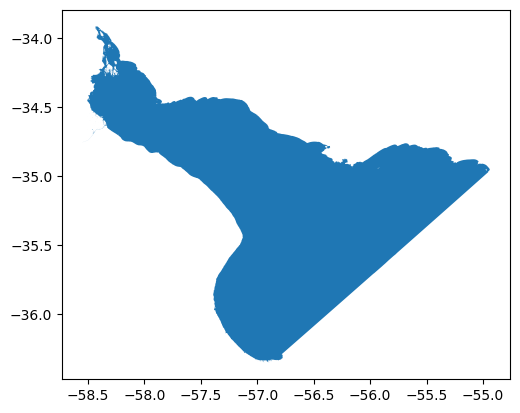

In [13]:
rio.plot()

In [6]:
bares.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 454 entries, ('node', np.int64(479757409)) to ('way', np.int64(1363149845))
Data columns (total 92 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   geometry                     454 non-null    geometry
 1   amenity                      454 non-null    str     
 2   name                         430 non-null    str     
 3   addr:city                    207 non-null    str     
 4   addr:country                 196 non-null    str     
 5   addr:housenumber             182 non-null    str     
 6   addr:street                  246 non-null    str     
 7   addr:suburb                  74 non-null     str     
 8   cuisine                      16 non-null     str     
 9   internet_access              32 non-null     str     
 10  old_name                     1 non-null      str     
 11  opening_hours                73 non-null     str     
 12  ch

In [18]:
import pandas as pd
import geopandas as gpd

# cargar CSV
df = pd.read_csv(
    "/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/GeoData/Delitos_Diciembre_2024.csv"
)

# renombrar columnas
df = df.rename(
    columns={
        "Latitud": "latitud",
        "Longitud": "longitud"
    }
)

# 🔥 convertir a numérico (MUY importante)
df["latitud"] = pd.to_numeric(
    df["latitud"],
    errors="coerce"
)

df["longitud"] = pd.to_numeric(
    df["longitud"],
    errors="coerce"
)

# 🔥 eliminar filas con NaN en coords
df = df.dropna(
    subset=["latitud", "longitud"]
)

# 🔥 filtrar coordenadas inválidas (muy recomendable)
df = df[
    (df["latitud"].between(-90, 90)) &
    (df["longitud"].between(-180, 180))
]

print("Filas restantes:", len(df))

# crear geometría
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitud"],
        df["latitud"]
    ),
    crs="EPSG:4326"
)

# guardar GeoJSON
gdf.to_file(
    "/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/GeoData/Delitos_Diciembre_2024.geojson",
    driver="GeoJSON"
)

print("GeoJSON creado correctamente.")

Filas restantes: 10734
GeoJSON creado correctamente.
